# AIE S3 — Bike Sharing Demand: Modelling & Evaluation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/python-ai-engineering/challenges/aie-s3-bike-demand.ipynb)

**Regression**, ranked on **−MAE**. The same data and the same
challenge as Session 2, where a linear model scored **−138.88**.

Challenge: <https://ml-arena.com/viewchallenge/183>

---

The data does not change; the model does. The plan:

1. keep a **test** set aside;
2. compare a linear model and a random forest on train **and** test;
3. tune the forest with a **grid search**, cross-validated on the
   train part only;
4. retrain the best model on all the data and submit.

---

## 0. Setup

In [3]:
!pip install -q mlarena-sdk

---

## 1. Get the data

Your key is on your ML-Arena **Profile** page.

In [4]:
import mlarena

API_KEY = "mlk_user_eeea0ac9a93256a6_798bce620dcbae5a7efe3bbf16a73f7d"   # <- paste yours here
CHALLENGE_ID = 183

client = mlarena.connect(api_key=API_KEY)
client.download_dataset(CHALLENGE_ID, ".")

['./X_train.csv', './y_train.csv', './X_test.csv']

---

## 2. Read it

In [5]:
import pandas as pd

X = pd.read_csv("X_train.csv")               # the hours you have a label for
y = pd.read_csv("y_train.csv")["prediction"]
X_submission = pd.read_csv("X_test.csv")     # the hours the leaderboard scores

print("X", X.shape, " X_submission", X_submission.shape)

X (13903, 13)  X_submission (3476, 13)


---

## 3. Keep a test set aside

The model never sees the test rows during `fit`, so its score on them
estimates the leaderboard before you submit.

`X` is in time order and the leaderboard scores the hours that come
after it, so `shuffle=False`: the test set is the **last 20%**.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("train", X_train.shape, " test", X_test.shape)
print("mean rentals per hour: train %.0f, test %.0f" % (y_train.mean(), y_test.mean()))

train (11122, 13)  test (2781, 13)
mean rentals per hour: train 151, test 268


The test hours are busier (268 against 151 bikes an hour): the system
grew over the two years. Every model will do worse on them.

---

## 4. Turn it into numbers

Same preparation as Session 2: the median for missing numbers,
`"unknown"` for missing text, one-hot encoding for the text. The
medians come from the **training rows only**, and the test columns
are aligned on the training ones.

In [7]:
def encode(frame, medians, columns=None):
    f = frame.drop(columns=["id"]).fillna(medians)
    for c in f.columns:
        if not pd.api.types.is_numeric_dtype(f[c]):
            f[c] = f[c].fillna("unknown")
    out = pd.get_dummies(f)
    return out if columns is None else out.reindex(columns=columns, fill_value=0)


medians = X_train.median(numeric_only=True)
X_train_enc = encode(X_train, medians)
X_test_enc = encode(X_test, medians, X_train_enc.columns)
X_train_enc.shape, X_test_enc.shape

((11122, 19), (2781, 19))

---

## 5. Two models, two scores

Each model is fitted on the training rows, then scored twice: on
those same rows (**train MAE**) and on the test rows it has never
seen (**test MAE**).

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


def evaluate(model):
    model.fit(X_train_enc, y_train)
    train_mae = mean_absolute_error(y_train, model.predict(X_train_enc))
    test_mae = mean_absolute_error(y_test, model.predict(X_test_enc))
    print(f"train MAE {train_mae:6.1f} | test MAE {test_mae:6.1f} | {model}")


evaluate(LinearRegression())
evaluate(RandomForestRegressor(n_estimators=1000, random_state=0, n_jobs=-1))

train MAE   85.0 | test MAE  146.3 | LinearRegression()
train MAE    8.0 | test MAE   53.0 | RandomForestRegressor(n_estimators=1000, n_jobs=-1, random_state=0)


**What happens?**

- Which model is better on the test set?
- The forest is almost perfect on the training rows. Is it as good on
  the test rows? What has it learned?
- The linear model is bad on both. What does that tell you?

**Try other hyperparameters.** Change the forest below, re-run it, and
watch **both** numbers:

- `max_depth` — how deep each tree can grow (5, 10, 20, …);
- `min_samples_leaf` — the fewest training hours in a leaf (5, 20, …);
- `max_features` — the share of columns each split looks at (0.3, 0.5, …);
- `n_estimators` — the number of trees. Does it change the gap?

In [17]:
evaluate(RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0, n_jobs=-1))
#evaluate(RandomForestRegressor(n_estimators=..., max_depth=..., random_state=0, n_jobs=-1))
#evaluate(RandomForestRegressor(n_estimators=..., max_depth=..., random_state=0, n_jobs=-1))

train MAE   24.4 | test MAE   52.5 | RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=0)


---

## 6. Grid search, cross-validated on the train part

Picking hyperparameters by looking at the test score uses the test
set to **choose**: after a few tries it no longer measures new data.
So the search only looks at the **train part**:

- `TimeSeriesSplit(n_splits=2)` cuts it in time order: fit on the
  first third, validate on the second; then fit on the first two
  thirds, validate on the last one. Always the past predicting the
  future, like the leaderboard.
- `return_train_score=True` keeps the train score of each fit.
- scikit-learn maximises a score, so the MAE comes back negated
  (`neg_mean_absolute_error`).

12 forests × 2 folds: expect a minute or two on Colab.

In [18]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

grid = {
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [1, 5, 20],
    "n_estimators": [10, 20, 50]
}
search = GridSearchCV(
    RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1), grid,
    cv=TimeSeriesSplit(n_splits=2), scoring="neg_mean_absolute_error",
    return_train_score=True,
)
search.fit(X_train_enc, y_train)
print("best:", search.best_params_)

best: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 50}


Each forest gets two scores, averaged over the two folds: **train MAE**
on the hours it was fitted on, **validation MAE** on the later hours
it had not seen. (scikit-learn names the second one `test`; it is
not your test set, which is still untouched.)

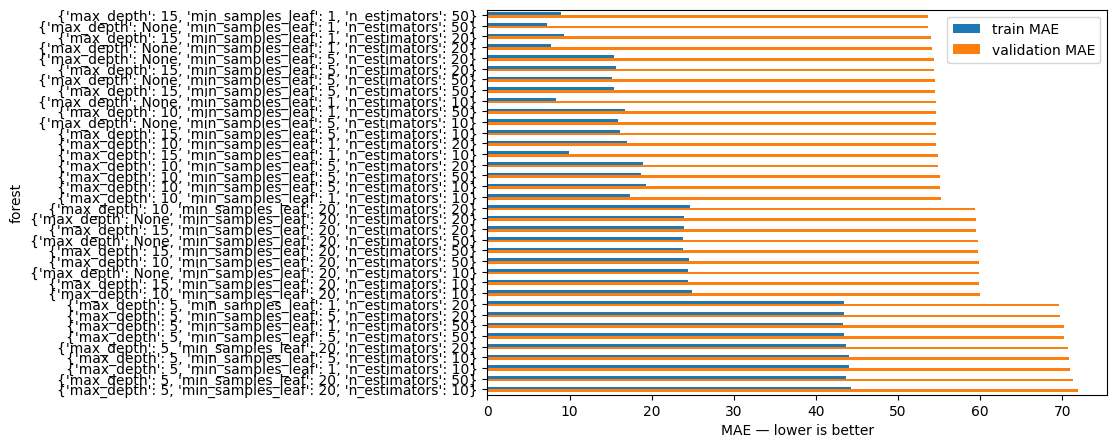

,forest,train MAE,validation MAE
20,"{'max_depth': 15, 'min_samples_leaf': 1, 'n_es...",9.0,53.7
29,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",7.3,53.7
19,"{'max_depth': 15, 'min_samples_leaf': 1, 'n_es...",9.4,54.0
28,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",7.7,54.1
31,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",15.5,54.4
22,"{'max_depth': 15, 'min_samples_leaf': 5, 'n_es...",15.7,54.4
32,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",15.2,54.5
23,"{'max_depth': 15, 'min_samples_leaf': 5, 'n_es...",15.4,54.5
27,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",8.3,54.6
11,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",16.7,54.7


In [19]:
import matplotlib.pyplot as plt

results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
results["train MAE"] = -results["mean_train_score"]
results["validation MAE"] = -results["mean_test_score"]
results["forest"] = results["params"].map(str)

ax = results.plot.barh(x="forest", y=["train MAE", "validation MAE"], figsize=(8, 5))
ax.invert_yaxis()   # best forest on top
ax.set_xlabel("MAE — lower is better")
plt.show()

results[["forest", "train MAE", "validation MAE"]].round(1)

Read the plot from the bottom up:

what model perform the best?

Now, once, the test set. `GridSearchCV` has already refitted the winner
on the whole train part, so `search` predicts directly.

In [20]:
test_mae = mean_absolute_error(y_test, search.predict(X_test_enc))
print(f"grid winner: test MAE {test_mae:.1f}")

grid winner: test MAE 53.0


53.4, as in section 5 — it is the same forest. This time the test set
checked a choice made without it.

---

## 7. Retrain on all the data and submit

The grid chose the hyperparameters. Retrain them on **all** 13,903
labelled hours: the test hours are the most recent ones, the closest
to the hours the leaderboard scores.

In [23]:
medians_all = X.median(numeric_only=True)
X_all_enc = encode(X, medians_all)
X_submission_enc = encode(X_submission, medians_all, X_all_enc.columns)

best_model = RandomForestRegressor(random_state=0, n_jobs=-1,
                                   **search.best_params_)
best_model.fit(X_all_enc, y)

submission = pd.DataFrame({"id": X_submission["id"],
                           "prediction": best_model.predict(X_submission_enc)})
submission.to_csv("submission.csv", index=False)
submission.head()

,id,prediction
0,te_65ff28c6cf3b,278.470556
1,te_fcf4be0b6635,591.380673
2,te_47c0ff3e2e1d,177.211810
3,te_438dce112a03,167.481759
4,te_d0b72cfc3b23,580.731319


In [24]:
result = client.submit(challenge_id=CHALLENGE_ID, files=["submission.csv"])
print(result)

{'attache_agent_id': 8624, 'agent_id': 8624, 'deploy': {'deployment_id': 8389, 'message': 'Deployment started successfully', 'status': 'deploy_queue'}}


In [25]:
client.leaderboard(CHALLENGE_ID).head(10)

,AgentName,AvatarKey,EloScore,EloVariance,FrontendPrecision,HasGpu,IsContinuous,IsEloRanked,IsMyAgent,LastRun,...,NumberOfRuns,Rank,RewardCi95,SimulationVersion,SubscriptionDate,TeamId,TeamMembers,TeamName,Username,agentAttachId
0,submission,shapes:77k1laip,1200.0,None,2,False,False,False,False,2026-09-10 10:16:47,...,1,1,None,file_v1,2026-09-10 10:12:55,None,[],None,raphael,8616
1,submission,None,1200.0,None,2,False,False,False,False,2026-09-10 12:48:07,...,1,2,None,file_v1,2026-09-10 12:44:47,None,[],None,anne-sophie,8623
2,submission,shapes:77k1laip,1200.0,None,2,False,False,False,False,2026-09-10 08:53:24,...,1,3,None,file_v1,2026-09-10 08:52:44,None,[],None,raphael,8614
3,submission,shapes:77k1laip,1200.0,None,2,False,False,False,False,2026-09-10 09:54:40,...,1,4,None,file_v1,2026-09-10 09:48:47,None,[],None,raphael,8615
4,submission,shapes:77k1laip,1200.0,None,2,False,False,False,False,2026-09-09 10:44:21,...,1,5,None,file_v1,2026-09-09 10:41:12,None,[],None,raphael,8556
5,Test_submission1,None,1200.0,None,2,False,False,False,False,2026-09-09 08:38:15,...,1,6,None,file_v1,2026-09-09 08:32:55,None,[],None,Felix-Bos,8553
6,submission,None,1200.0,None,2,False,False,False,False,2026-09-09 14:18:42,...,1,7,None,file_v1,2026-09-09 14:13:58,None,[],None,gabrielyehoudagozlan,8595
7,new,None,1200.0,None,2,False,False,False,False,2026-09-09 14:18:58,...,1,7,None,file_v1,2026-09-09 14:17:08,None,[],None,gabrielyehoudagozlan,8596
8,submission,None,1200.0,None,2,False,False,False,False,2026-09-09 14:11:21,...,1,9,None,file_v1,2026-09-09 14:10:57,None,[],None,gabrielyehoudagozlan,8592
9,new,None,1200.0,None,2,False,False,False,False,2026-09-09 14:41:16,...,1,9,None,file_v1,2026-09-09 14:34:54,None,[],None,gabrielyehoudagozlan,8600


About **−47.6**, against **−138.88** for the Session 2 line: the same
columns, another model.

---

## 8. Your turn: other models

Same protocol for other model families: fit on train, compare train
and test MAE, then a grid search with `TimeSeriesSplit` on the train
part. No code this time.

- `Ridge` and `Lasso` — a linear model with a penalty, `alpha`;
- `KNeighborsRegressor` — `n_neighbors`;
- `SVR` — `C`, `gamma`, `kernel` (slow on 11,000 rows: start on a
  subsample);
- `MLPRegressor` — `hidden_layer_sizes`, `alpha`, `max_iter`;
- `HistGradientBoostingRegressor` — `learning_rate`, `max_iter`,
  `max_leaf_nodes`.

All of them except the boosting need a `StandardScaler` in front:
`make_pipeline(StandardScaler(), SVR())`. For each one: does it
underfit or overfit? Does the grid search help?

Improve your local evaluation — the validation MAE of the search,
then one look at the test MAE. When a model clearly beats the forest,
retrain it on all the data and submit: the leaderboard is a check,
not a search space.